In [1]:
from rdkit.Chem import Descriptors, Lipinski, QED
import math
import pickle

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

import os
import os.path as op

_fscores = None


def readFragmentScores(name='fpscores'):
    import gzip
    global _fscores
    # generate the full path filename:
    if name == "fpscores":
        name = op.join(os.getcwd(), name)
        # name = op.join(op.dirname(__file__), name)
    data = pickle.load(gzip.open('%s.pkl.gz' % name))
    outDict = {}
    for i in data:
        for j in range(1, len(i)):
            outDict[i[j]] = float(i[0])
    _fscores = outDict


def numBridgeheadsAndSpiro(mol, ri=None):
    nSpiro = rdMolDescriptors.CalcNumSpiroAtoms(mol)
    nBridgehead = rdMolDescriptors.CalcNumBridgeheadAtoms(mol)
    return nBridgehead, nSpiro


def calculateScore(m):
    if _fscores is None:
        readFragmentScores()

    # fragment score
    fp = rdMolDescriptors.GetMorganFingerprint(m,
                                               2)  # <- 2 is the *radius* of the circular fingerprint
    fps = fp.GetNonzeroElements()
    score1 = 0.
    nf = 0
    for bitId, v in fps.items():
        nf += v
        sfp = bitId
        score1 += _fscores.get(sfp, -4) * v
    score1 /= nf

    # features score
    nAtoms = m.GetNumAtoms()
    nChiralCenters = len(Chem.FindMolChiralCenters(m, includeUnassigned=True))
    ri = m.GetRingInfo()
    nBridgeheads, nSpiro = numBridgeheadsAndSpiro(m, ri)
    nMacrocycles = 0
    for x in ri.AtomRings():
        if len(x) > 8:
            nMacrocycles += 1

    sizePenalty = nAtoms ** 1.005 - nAtoms
    stereoPenalty = math.log10(nChiralCenters + 1)
    spiroPenalty = math.log10(nSpiro + 1)
    bridgePenalty = math.log10(nBridgeheads + 1)
    macrocyclePenalty = 0.
    # ---------------------------------------
    # This differs from the paper, which defines:
    # macrocyclePenalty = math.log10(nMacrocycles+1)
    # This form generates better results when 2 or more macrocycles are present
    if nMacrocycles > 0:
        macrocyclePenalty = math.log10(2)

    score2 = 0. - sizePenalty - stereoPenalty - spiroPenalty - bridgePenalty - macrocyclePenalty

    # correction for the fingerprint density
    # not in the original publication, added in version 1.1
    # to make highly symmetrical molecules easier to synthetise
    score3 = 0.
    if nAtoms > len(fps):
        score3 = math.log(float(nAtoms) / len(fps)) * .5

    sascore = score1 + score2 + score3

    # need to transform "raw" value into scale between 1 and 10
    min = -4.0
    max = 2.5
    sascore = 11. - (sascore - min + 1) / (max - min) * 9.
    # smooth the 10-end
    if sascore > 8.:
        sascore = 8. + math.log(sascore + 1. - 9.)
    if sascore > 10.:
        sascore = 10.0
    elif sascore < 1.:
        sascore = 1.0

    return sascore


In [2]:
# sascore and QED calcualte test

AZD5305_MOL = Chem.MolFromSmiles("O=C(C1=NC=C(N2CCN(CC3=CC(N4)=C(N=C3)C=C(CC)C4=O)CC2)C=C1)NC")
sa_score = calculateScore(AZD5305_MOL)
qed = QED.qed(AZD5305_MOL)

print(sa_score)
print(qed)

2.5493162509850613
0.6679383981149386


In [3]:
# generate script example

import argparse
import pickle
from pathlib import Path

import dgl
import rdkit
import torch
from rdkit import RDLogger
from tqdm.auto import tqdm

from model.gcpg import GCPG
from utils.file_utils import load_phar_file
from utils.utils import seed_torch

RDLogger.DisableLog('rdApp.*')

def load_model(model_path, tokenizer_path):
    with open(tokenizer_path, 'rb') as f:
        tokenizer = pickle.load(f)

    model_params = {
        "max_len": 128,
        "cond_dim": 7,
        "pp_v_dim": 7 + 1,
        "pp_e_dim": 1,
        "pp_encoder_n_layer": 4,
        "hidden_dim": 384,
        "n_layers": 8,
        "ff_dim": 1024,
        "n_head": 8,
    }

    model = GCPG(model_params, tokenizer)
    states = torch.load(model_path, map_location='cpu')
    print(model.load_state_dict(states['model'], strict=False))

    return model, tokenizer

def format_smiles(smiles):
    mol = rdkit.Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    smiles = rdkit.Chem.MolToSmiles(mol, isomericSmiles=True)

    return smiles

input_file = Path("data/phar_PARP1.posp")
assert input_file.suffix in ('.edgep', '.posp')
model_path = "results/rs_mapping/fold0_epoch32.pth"
tokenizer_path = "results/rs_mapping/tokenizer_r_iso.pkl"
n_mol = 100
device = 'cpu'
batch_size = 128
seed = -1

In [4]:
model, tokenizer = load_model(model_path, tokenizer_path)
g = load_phar_file(input_file)
g_batch = [g] * batch_size
g_batch = dgl.batch(g_batch).to(device)
n_epoch = (n_mol + batch_size - 1) // batch_size

<All keys matched successfully>


In [5]:
# logP set to 3 ; SA set to 2

res_total = []
MW = 400
logP = 3
QED = 0.6
SAS = 2
RotaNumBonds = 4
Score = 0
Smi = 0

MW_tensor = torch.tensor([MW], dtype=torch.float32).repeat(1, batch_size)
logP_tensor = torch.tensor([logP], dtype=torch.float32).repeat(1, batch_size)
QED_tensor = torch.tensor([QED], dtype=torch.float32).repeat(1, batch_size)
SAS_tensor = torch.tensor([SAS], dtype=torch.float32).repeat(1, batch_size)
RotaNumBonds_tensor = torch.tensor([RotaNumBonds], dtype=torch.float32).repeat(1, batch_size)
Score_tensor = torch.tensor([Score], dtype=torch.float32).repeat(1, batch_size)
Smi_tensor = torch.tensor([Smi], dtype=torch.float32).repeat(1, batch_size)

conditions = [MW_tensor, logP_tensor, QED_tensor, SAS_tensor, RotaNumBonds_tensor, Score_tensor, Smi_tensor]

res = [] 
for i in tqdm(range(n_epoch)):
    res.extend(
        tokenizer.get_text(model.generate(pp_graphs=g_batch, conditions=conditions)))

res = res[:n_mol]
res_total.extend(res)

res_total = [format_smiles(i) for i in res_total]            
res_total = [i for i in res_total if i]
res_total = list(set(res_total))

  0%|          | 0/1 [00:00<?, ?it/s]

In [6]:
res_total[1]

'Cc1ccccc1S(=O)(=O)N1CCN(Cc2cc(C(=O)O)c3ccccc3c2)CC1'

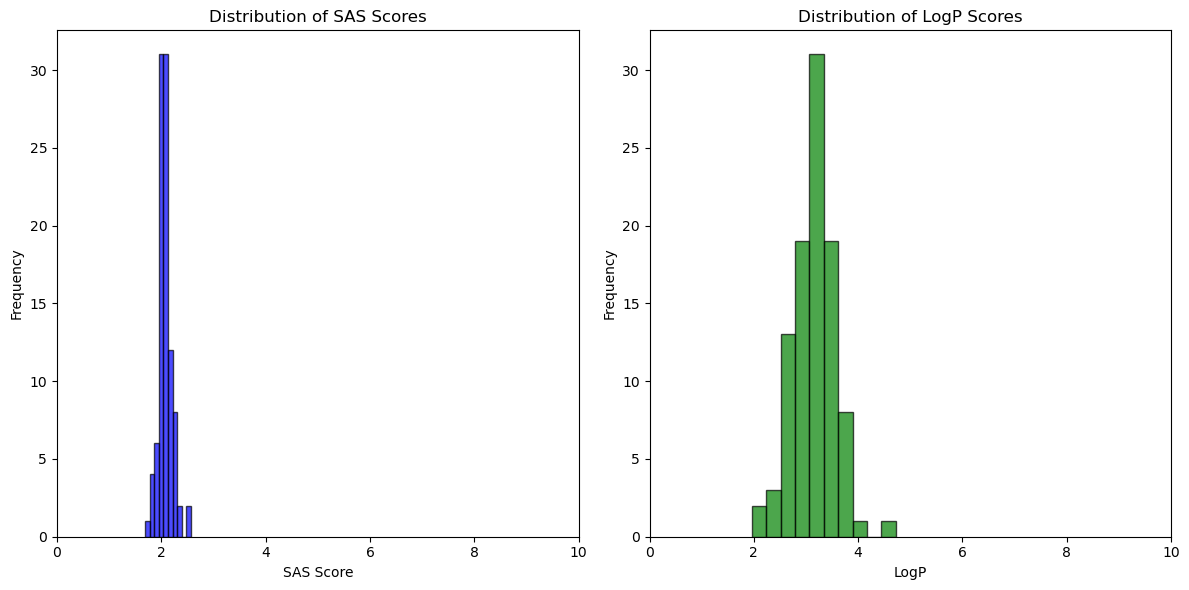

In [7]:
sas_score_list = [calculateScore(Chem.MolFromSmiles(smi)) for smi in res_total]
lopP_list = [Descriptors.MolLogP(Chem.MolFromSmiles(smi)) for smi in res_total]


import matplotlib.pyplot as plt
# 创建图形和两个子图
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 绘制 SAS 分数的分布图
axes[0].hist(sas_score_list, bins=10, color='blue', edgecolor='black', alpha=0.7)
axes[0].set_title("Distribution of SAS Scores")
axes[0].set_xlabel("SAS Score")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim(0, 10)  # 设置横坐标范围为 0 到 10

# 绘制 LogP 分数的分布图
axes[1].hist(lopP_list, bins=10, color='green', edgecolor='black', alpha=0.7)
axes[1].set_title("Distribution of LogP Scores")
axes[1].set_xlabel("LogP")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(0, 10)  # 设置横坐标范围为 0 到 10

# 调整子图之间的间距
plt.tight_layout()

# 显示图形
plt.show()

  0%|          | 0/1 [00:00<?, ?it/s]

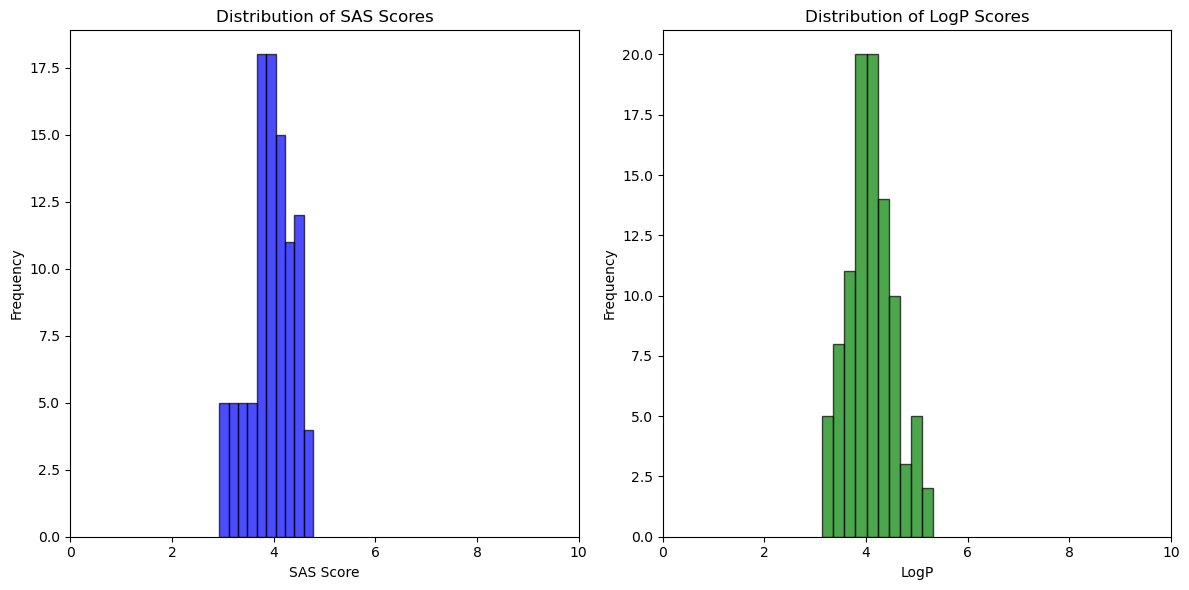

In [8]:
# logP set to 4 ; SA set to 4

res_total = []
MW = 400
logP = 4
QED = 0.6
SAS = 4
RotaNumBonds = 4
Score = 0
Smi = 0

MW_tensor = torch.tensor([MW], dtype=torch.float32).repeat(1, batch_size)
logP_tensor = torch.tensor([logP], dtype=torch.float32).repeat(1, batch_size)
QED_tensor = torch.tensor([QED], dtype=torch.float32).repeat(1, batch_size)
SAS_tensor = torch.tensor([SAS], dtype=torch.float32).repeat(1, batch_size)
RotaNumBonds_tensor = torch.tensor([RotaNumBonds], dtype=torch.float32).repeat(1, batch_size)
Score_tensor = torch.tensor([Score], dtype=torch.float32).repeat(1, batch_size)
Smi_tensor = torch.tensor([Smi], dtype=torch.float32).repeat(1, batch_size)

conditions = [MW_tensor, logP_tensor, QED_tensor, SAS_tensor, RotaNumBonds_tensor, Score_tensor, Smi_tensor]

res = [] 
for i in tqdm(range(n_epoch)):
    res.extend(
        tokenizer.get_text(model.generate(pp_graphs=g_batch, conditions=conditions)))

res = res[:n_mol]
res_total.extend(res)

res_total = [format_smiles(i) for i in res_total]            
res_total = [i for i in res_total if i]
res_total = list(set(res_total))


sas_score_list = [calculateScore(Chem.MolFromSmiles(smi)) for smi in res_total]
lopP_list = [Descriptors.MolLogP(Chem.MolFromSmiles(smi)) for smi in res_total]


import matplotlib.pyplot as plt
# 创建图形和两个子图
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 绘制 SAS 分数的分布图
axes[0].hist(sas_score_list, bins=10, color='blue', edgecolor='black', alpha=0.7)
axes[0].set_title("Distribution of SAS Scores")
axes[0].set_xlabel("SAS Score")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim(0, 10)  # 设置横坐标范围为 0 到 10

# 绘制 LogP 分数的分布图
axes[1].hist(lopP_list, bins=10, color='green', edgecolor='black', alpha=0.7)
axes[1].set_title("Distribution of LogP Scores")
axes[1].set_xlabel("LogP")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(0, 10)  # 设置横坐标范围为 0 到 10

# 调整子图之间的间距
plt.tight_layout()

# 显示图形
plt.show()
